In [2]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
file_path = r"datos_preprocesados_winsorizado.csv"

df = pd.read_csv(file_path)  

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Aseguramos que el dataset esté ordenado por 'casa_id' y 'timestamp'
df.sort_values(['casa_id', 'timestamp'], inplace=True)

# (Si no existen aún) Generamos features temporales: 
# Nota: Estos campos pueden ya estar presentes del preprocesamiento, pero los incluimos para reforzar.
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek

# Crear lag features por cada casa
df['lag_1'] = df.groupby('casa_id')['consumo_kwh'].shift(1)   # consumo 1 hora anterior
df['lag_24'] = df.groupby('casa_id')['consumo_kwh'].shift(24)  # consumo a la misma hora del día anterior

# Eliminamos filas sin lag (al comienzo de la serie para cada casa)
df = df.dropna(subset=['lag_1', 'lag_24'])

print("Dataset con features y lag creado:")
print(df.head())


Dataset con features y lag creado:
    casa_id           timestamp  consumo_kwh  coste_euros  year  month  day  \
24       37 2017-06-01 01:00:00        0.512     0.076129  2017      6    1   
25       37 2017-06-01 02:00:00        0.247     0.034476  2017      6    1   
26       37 2017-06-01 03:00:00        0.168     0.022643  2017      6    1   
27       37 2017-06-01 04:00:00        0.171     0.025033  2017      6    1   
28       37 2017-06-01 05:00:00        0.146     0.023500  2017      6    1   

    hour  dayofweek  is_weekend  is_saturday   lag_1  lag_24  
24     1          3           0        False  0.6135   0.176  
25     2          3           0        False  0.5120   0.222  
26     3          3           0        False  0.2470   0.195  
27     4          3           0        False  0.1680   0.163  
28     5          3           0        False  0.1710   0.235  


In [6]:
# Ordenamos globalmente por timestamp
df.sort_values('timestamp', inplace=True)

# Definimos el índice de corte (80% de los datos)
split_index = int(len(df) * 0.8)
df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print("Tamaño del conjunto de entrenamiento:", len(df_train))
print("Tamaño del conjunto de prueba:", len(df_test))


Tamaño del conjunto de entrenamiento: 2132735
Tamaño del conjunto de prueba: 533184


In [7]:
# Seleccionar las features para el modelo
features = ['hour', 'day', 'month', 'dayofweek', 'lag_1', 'lag_24']
target = 'consumo_kwh'

X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

# Entrenar el modelo
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predecir en el conjunto de test
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 0.08272507881806808
RMSE: 0.12583835859507464


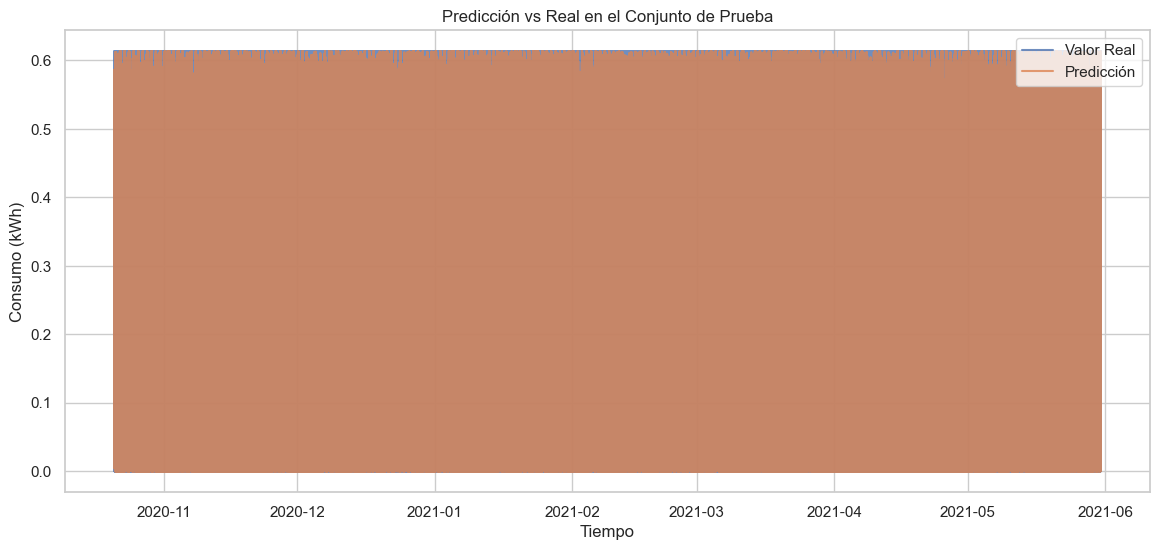

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df_test['timestamp'], y_test, label='Valor Real', alpha=0.8)
plt.plot(df_test['timestamp'], y_pred, label='Predicción', alpha=0.8)
plt.xlabel('Tiempo')
plt.ylabel('Consumo (kWh)')
plt.title('Predicción vs Real en el Conjunto de Prueba')
plt.legend()
plt.show()


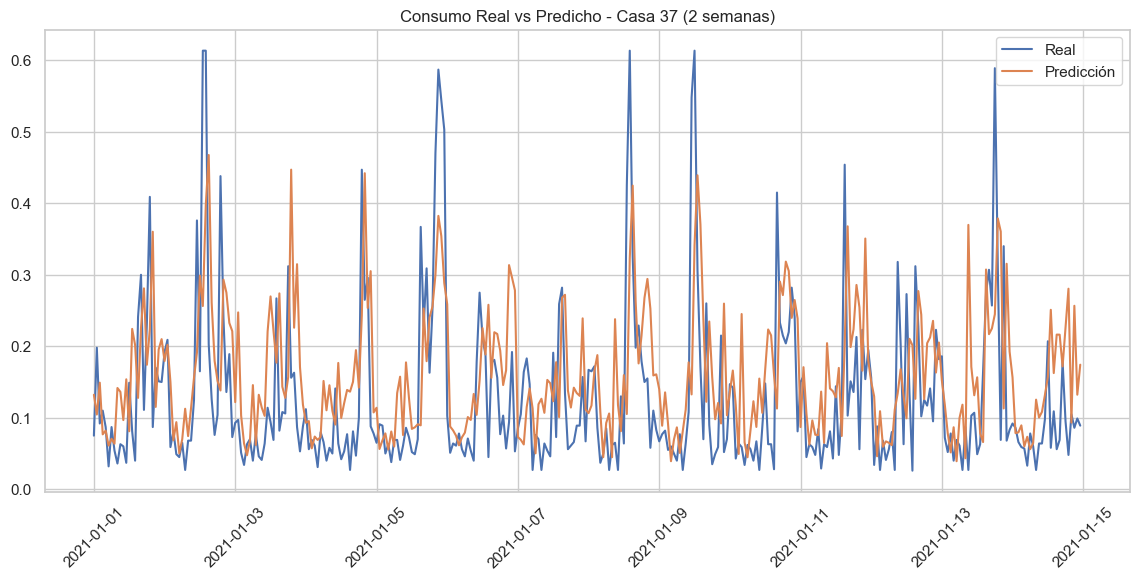

In [9]:
# Filtrar la casa 37 en el conjunto de test
df_test_37 = df_test[df_test['casa_id'] == 37]

# Elegir, por ejemplo, 2 semanas del test
fecha_inicial = '2021-01-01'
fecha_final = '2021-01-15'
df_test_37_period = df_test_37[(df_test_37['timestamp'] >= fecha_inicial) & 
                               (df_test_37['timestamp'] < fecha_final)]

# Predecimos sobre ese subset
X_test_37_period = df_test_37_period[features]
y_test_37_period = df_test_37_period[target]
y_pred_37_period = model.predict(X_test_37_period)

# Graficamos
plt.figure(figsize=(14,6))
plt.plot(df_test_37_period['timestamp'], y_test_37_period, label='Real')
plt.plot(df_test_37_period['timestamp'], y_pred_37_period, label='Predicción')
plt.xticks(rotation=45)
plt.title('Consumo Real vs Predicho - Casa 37 (2 semanas)')
plt.legend()
plt.show()
